In [1]:
import numpy as np
import dynesty
from dynesty import NestedSampler
from dynesty import utils as dyfunc
import matplotlib.pyplot as plt
import corner
from dynesty import DynamicNestedSampler
import g_shell as gs
import morphZ
# import logging
# from morphZ import setup_logging ; setup_logging(level=logging.INFO)
from scipy.special import logsumexp


In [2]:
 

# Prior cube: [-L, L]^D 
L = 6.0
ndim = 30
prior_volume = (2*L)**ndim

# Parameters of the twin shells (from paper)
w1 = w2 = 0.1  # thickness of both shells
r1 = r2 = 2.0  # radius of both shells
c1 = np.array([-3.5] + [0.0] * (ndim - 1))  # center of first shell
c2 = np.array([3.5] + [0.0] * (ndim - 1))   # center of second shell

def logprior(theta):
    """Uniform prior over [-L, L]^D."""
    if np.all(np.abs(theta) <= L):
        return -np.log(prior_volume)
    else:
        return -np.inf

def loglikelihood(theta):
    """
    Twin Gaussian shell log-likelihood from equation (38) in the paper.
    L(θ) = (1/√(2πw₁)) * exp[-(|θ-c₁|-r₁)²/(2w₁²)] + (1/√(2πw₂)) * exp[-(|θ-c₂|-r₂)²/(2w₂²)]
    """
    # Distance from centers
    r_c1 = np.linalg.norm(theta - c1)
    r_c2 = np.linalg.norm(theta - c2)
    
    # Log-likelihood components for each shell
    # Note: We work in log space for numerical stability
    log_norm1 = -0.5 * np.log(2 * np.pi * w1**2)
    log_norm2 = -0.5 * np.log(2 * np.pi * w2**2)
    
    log_exp1 = log_norm1 - 0.5 * ((r_c1 - r1) / w1)**2
    log_exp2 = log_norm2 - 0.5 * ((r_c2 - r2) / w2)**2
    
    # Use logsumexp for numerical stability when adding exponentials
    return logsumexp([log_exp1, log_exp2])

def prior_transform(u):
    """
    Map unit cube [0,1]^D to [-L, L]^D.
    u: array in [0,1]^D
    """
    return -L + 2*L*u

# Optional: Visualization function for 2D case
def plot_twin_shells_2d():
    """Plot the twin Gaussian shells for visualization (2D only)."""
    if ndim != 2:
        print("Visualization only available for 2D case")
        return
    
    # Create grid
    x = np.linspace(-6, 6, 200)
    y = np.linspace(-6, 6, 200)
    X, Y = np.meshgrid(x, y)
    
    # Evaluate likelihood on grid
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            theta = np.array([X[i,j], Y[i,j]])
            Z[i,j] = np.exp(loglikelihood(theta))
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(X, Y, Z, levels=50, cmap='viridis')
    plt.colorbar(label='Likelihood')
    plt.xlabel('θ₁')
    plt.ylabel('θ₂')
    plt.title('Twin Gaussian Shells')
    
    # Mark centers
    plt.plot(c1[0], c1[1], 'r*', markersize=15, label='Center 1')
    plt.plot(c2[0], c2[1], 'r*', markersize=15, label='Center 2')
    
    # Draw circles showing the shell radii
    circle1 = plt.Circle(c1[:2], r1, fill=False, color='red', linestyle='--', alpha=0.7)
    circle2 = plt.Circle(c2[:2], r2, fill=False, color='red', linestyle='--', alpha=0.7)
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)
    
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage with dynesty
def run_dynesty_example():
    """Example of how to use this with dynesty."""
    try:
        import dynesty
        from dynesty import plotting as dyplot
        
        # Run nested sampling
        sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim)
        sampler.run_nested()
        results = sampler.results
        
        print(f"Log evidence: {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}")
        
        # Plot results
        fig, axes = dyplot.runplot(results)
        plt.show()
        
        return results
        
    except ImportError:
        print("Dynesty not installed. Install with: pip install dynesty")
        return None

# Analytical log-evidence values from the paper (for reference)
analytical_logz = {
    20: -36.09, # 20D case from paper
    30: -60.13  # 30D case from paper
}



if __name__ == "__main__":
    print(f"Twin Gaussian Shell Problem Setup:")
    print(f"Dimensions: {ndim}")
    print(f"Prior bounds: [{-L}, {L}]^{ndim}")
    print(f"Shell centers: c1={c1}, c2={c2}")
    print(f"Shell radii: r1={r1}, r2={r2}")
    print(f"Shell widths: w1={w1}, w2={w2}")
    
    if ndim == 2:
        print("\nGenerating 2D visualization...")
        plot_twin_shells_2d()
    
    # Uncomment to run dynesty example
    # results = run_dynesty_example()


# -------------------------------
# Run dynesty Nested Sampling
# -------------------------------
NN = 1

log_z_NS = np.zeros(NN)
log_z_NS_err = np.zeros(NN)

for i in range(NN):
# Set up the sampler
    sampler = NestedSampler(
        loglikelihood,
        prior_transform,
        ndim,
        nlive=100,      # number of live points; increase for accuracy
        sample="rwalk",  # random-walk proposals; can try "unif", "slice"
        bound="multi",   # bounding method ("multi" good for multimodal)
    )
    # sampler = DynamicNestedSampler(
    #     loglikelihood,
    #     prior_transform,
    #     ndim,
    #     nlive=4000,
    #     )

    print("Running dynesty Nested Sampling on Gaussian shell...")
    sampler.run_nested(dlogz=0.1,print_progress=True)
    # sampler.run_nested(dlogz_init=0.1,print_progress=True)
    res = sampler.results
    samples, weights = res.samples, np.exp(res.logwt - res.logz[-1])
    posterior_samples = dyfunc.resample_equal(samples, weights)
    # -------------------------------
    # Report results
    # -------------------------------
    log_z_NS[i] = res.logz[-1]
    log_z_NS_err[i] = res.logzerr[-1]
true_lnZ = {10: -14.59, 30: -60.13}.get(ndim)
print("\n==== RESULTS ====")
print(f"dynesty estimated logZ = {log_z_NS.mean():.3f} ± {log_z_NS_err.mean():.3f}")
print(f"True logZ (literature) = {true_lnZ:.3f}")
print(f"Error = {log_z_NS.mean()- true_lnZ:.3f}")


Twin Gaussian Shell Problem Setup:
Dimensions: 30
Prior bounds: [-6.0, 6.0]^30
Shell centers: c1=[-3.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0. ], c2=[3.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
Shell radii: r1=2.0, r2=2.0
Shell widths: w1=0.1, w2=0.1
Running dynesty Nested Sampling on Gaussian shell...


5484it [00:12, 425.82it/s, +100 | bound: 396 | nc: 1 | ncall: 259156 | eff(%):  2.156 | loglstar:   -inf <  1.384 <    inf | logz: -50.828 +/-  0.713 | dlogz:  0.001 >  0.100]


==== RESULTS ====
dynesty estimated logZ = -50.828 ± 0.828
True logZ (literature) = -60.130
Error = 9.302


In [4]:
import importlib
from nismo import plot_nested_progress
from nismo import CallableModel, NISMOSampler, MorphProposal, RWalkSettings, EnsembleMoveWeights,SRWalkSettings
from nismo.diagnostics import summarize
from nismo import EnsembleRWalkSettings
from nismo.plotting import plot_run, plot_weight_health
from nismo import StoppingCriterionConfig, StoppingPolicy
from nismo import SRWalkSettings, ParallelSettings


# importlib.reload(nismo)

# stopping = StoppingPolicy(
#     criteria=(
#         StoppingCriterionConfig(
#             name="live_logz_error",
#             tolerance=1e-2,
#         ),
#         StoppingCriterionConfig(
#             name="logz_stability",
#             tolerance=1e-2,
#         ),
#     ),
#     mode="all",
#     consecutive=2,
#     min_iterations=10,
#     stability_window=10,
# )


labels = [f"x{i}" for i in range(ndim)]
model = CallableModel(
    ndim=ndim,
    parameter_names=labels,
    log_likelihood_fn=loglikelihood,
    log_prior_fn=logprior,
    vectorized=False,
)
importance_dist = MorphProposal.fit(
    posterior_samples[::5,:],
    param_names=model.parameter_names,
    morph_type="2_group",
    kde_bw="silverman",
)
settings = SRWalkSettings(
    n_steps=75,
    covariance_shrinkage=0.1
    )
nismo_sampler = NISMOSampler(
    model=model,
    importance_morph=importance_dist,
    proposal_scheme="s-rwalk",
    srwalk_settings=settings,
    n_live=50,
    rng=1234,
    output_path="runs/nismo_run_001",
)

parallel= ParallelSettings(n_workers=4)

nismo_result = nismo_sampler.run(
    dlogz=0.1,
    progress=True
)
nismo_result.save("gaussian_shell_nismo_result.pkl")

INFO:morphZ.Nth_TC:Auto-thinning samples to 300 for faster TC computation (n_dims=30, n_order=2).


MI pairs:   0%|          | 0/435 [00:00<?, ?it/s]

INFO:morphZ.Nth_TC:Top 10 MI pairs:
INFO:morphZ.Nth_TC:  x4 — x9 : 0.107484
INFO:morphZ.Nth_TC:  x17 — x25 : 0.104428
INFO:morphZ.Nth_TC:  x11 — x15 : 0.098166
INFO:morphZ.Nth_TC:  x12 — x27 : 0.098114
INFO:morphZ.Nth_TC:  x14 — x25 : 0.097910
INFO:morphZ.Nth_TC:  x13 — x15 : 0.096513
INFO:morphZ.Nth_TC:  x2 — x15 : 0.095992
INFO:morphZ.Nth_TC:  x1 — x16 : 0.094913
INFO:morphZ.Nth_TC:  x4 — x24 : 0.094746
INFO:morphZ.Nth_TC:  x2 — x23 : 0.093954
INFO:morphZ.Nth_TC:All MI pairs saved to /tmp/nismo-morphz-tc-eci0cjay/params_2-order_TC.json


NISMO nlive=50: iter: 1 [00:00,  1.30it/s, ncall=125, eff=1.3%, logZ=-61.726, logZerr=0.145, H=1.050, dlog(z)=…

PosixPath('gaussian_shell_nismo_result.pkl')

In [5]:
diagnostics = summarize(nismo_result)

print("NISMO success:", nismo_result.success)
print("Termination:", nismo_result.termination_reason)
print(f"delta NISMO logZ:    {nismo_result.logz-true_lnZ:.3f} ± {nismo_result.logzerr:.3f}")
print(f"delta Dynesty logZ: {res.logz[-1]-true_lnZ:.3f} ± {res.logzerr[-1]:.3f}")
print(f"Reference:    {true_lnZ:.3f}")
print("Iterations:", nismo_result.niter)
print("Likelihood calls:", nismo_result.n_likelihood_calls)
print("Diagnostics:", diagnostics)

# for warning in nismo_result.warnings:
#     print("WARNING:", warning)

history = nismo_result.history


NISMO success: True
Termination: remaining_evidence
delta NISMO logZ:    -0.963 ± 0.183
delta Dynesty logZ: 9.302 ± 0.828
Reference:    -60.130
Iterations: 339
Likelihood calls: 25475
Diagnostics: RunDiagnostics(posterior_ess=277.6341445386508, relative_posterior_ess=0.7137124538268658, proposal_acceptance_fraction=0.013333333333333334, maximum_proposals_per_replacement=75, thresholds_monotone=True, conservative_log_remaining=-61.07845480688182, final_remaining_fraction=0.09432464907739896, final_remaining_dlogz=0.09907436947053222, final_live_ess=16.435317453510624, final_live_mean_rse=0.20415225598907402, final_live_logz_error=0.019256589904528727, final_logz_stability=0.003117352796927264, final_stopping_streak=1, queue_efficiency=1.0, compute_efficiency=1.0)


/tmp/ipykernel_187281/3214460200.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


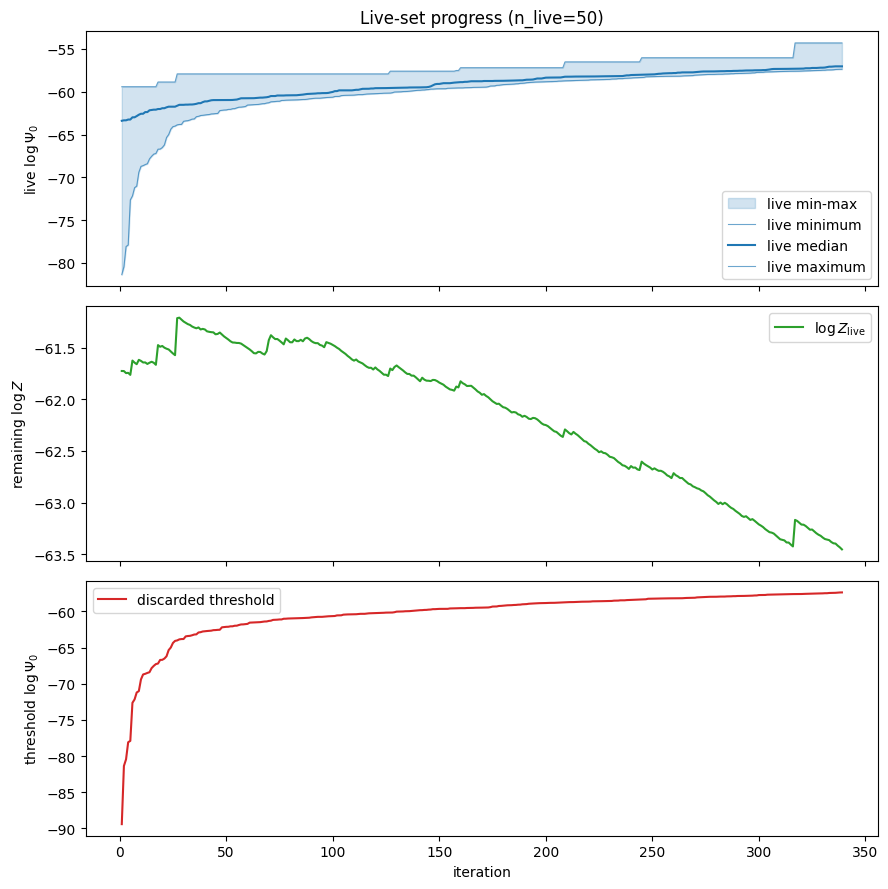

In [6]:
from nismo import plot_nested_progress

figure, axes = plot_nested_progress(nismo_result)
figure.show()
figure.savefig("nested_progress.png", dpi=150)

(5000, 30)


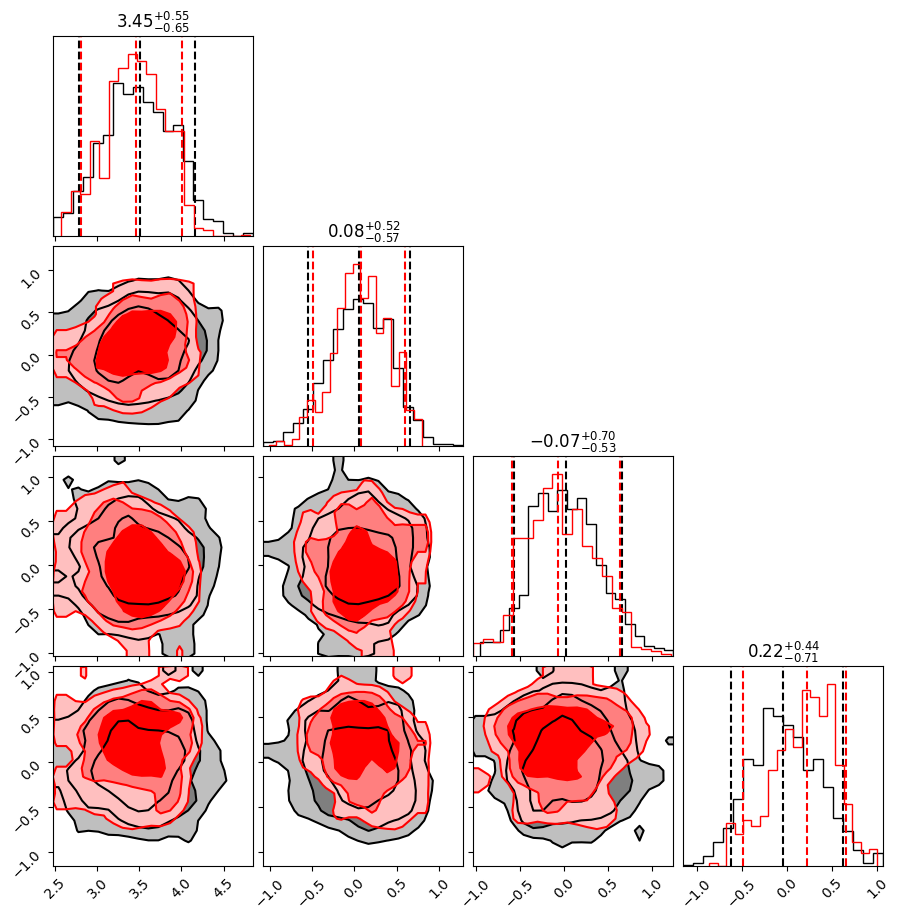

In [7]:
equal_samples = nismo_result.resample_equal(
    rng=123,          # required for reproducibility
    n_samples=5000,
)

print(equal_samples.shape)  # (10000, ndim)

fig = corner.corner(
    posterior_samples[::2,:4], bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
corner.corner(
    equal_samples[:,:4],color="red", bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fig=fig,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
plt.show()